# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

## Used Car Price Drivers

**Goal:** Understand what factors make a used car more or less expensive, and translate the findings into inventory/pricing guidance for a used car dealership.

We will follow the CRISP-DM lifecycle:
1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling  
5. Evaluation  
6. Deployment  


### <font color='orange'>1. Business Understanding</font>

<font color='orange'>
From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.
</font>

From a **business** perspective, we want to know what characteristics increase/decrease the market price of a used vehicle so the dealership can:
- stock inventory that matches consumer preferences,
- price vehicles competitively, and
- avoid inventory that is hard to sell or will require steep discounts.

**Data task reframing:**  
We will treat this as a **supervised regression** problem where the target variable is `price`.  
Given observed vehicle attributes (e.g., age/year, mileage/odometer, make/model, condition, drivetrain, fuel type, title status, etc.), we will:
- build predictive models for price, and
- interpret the strongest drivers (feature effects) to infer what consumers value.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 200)


### <font color='orange'>2. Data Understanding</font>

<font color='orange'>
After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.
</font>


Typical steps to understand the dataset and identify quality issues:
1. Load the dataset; inspect rows/columns, data types, and basic statistics.
2. Check **missingness** patterns (which columns are frequently missing, and whether missingness is systematic).
3. Inspect the **target** (`price`) distribution and look for impossible values/outliers (e.g., 0, extremely high prices).
4. Explore relationships between `price` and key predictors:
   - numeric: year/age, odometer
   - categorical: manufacturer, model, condition, fuel, transmission, drive, title status, etc.
5. Identify data quality issues:
   - duplicates / IDs
   - inconsistent categories (spelling variants)
   - implausible years or odometers
   - high-cardinality fields (e.g., model) and how to handle them


In [4]:
DATA_PATH = "data/vehicles.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [5]:
display(df.info())

missing = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
display(missing.to_frame("missing_%").head(15))

display(df.describe(include="all").T.head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

None

,missing_%
size,71.8
cylinders,41.6
condition,40.8
VIN,37.7
drive,30.6
paint_color,30.5
type,21.8
manufacturer,4.1
title_status,1.9
model,1.2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,426880.0,NaN,NaN,NaN,7311486634.224333,4473170.412559,7207408119.0,7308143339.25,7312620821.0,7315253543.5,7317101084.0
region,426880,404,columbus,3608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,426880.0,NaN,NaN,NaN,75199.033187,12182282.173604,0.0,5900.0,13950.0,26485.75,3736928711.0
year,425675.0,NaN,NaN,NaN,2011.235191,9.45212,1900.0,2008.0,2013.0,2017.0,2022.0
manufacturer,409234,42,ford,70985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,421603,29649,f-150,8009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,252776,6,good,121456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cylinders,249202,8,6 cylinders,94169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel,423867,5,gas,356209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odometer,422480.0,NaN,NaN,NaN,98043.331443,213881.500798,0.0,37704.0,85548.0,133542.5,10000000.0


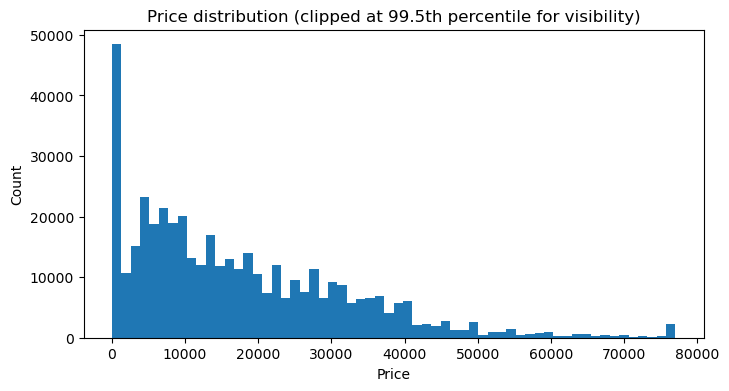

Price <= 0: 32895
Price > 200,000: 124


In [6]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(df["price"].clip(upper=df["price"].quantile(0.995)), bins=60)
ax.set_title("Price distribution (clipped at 99.5th percentile for visibility)")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
plt.show()

print("Price <= 0:", (df["price"]<=0).sum())
print("Price > 200,000:", (df["price"]>200000).sum())


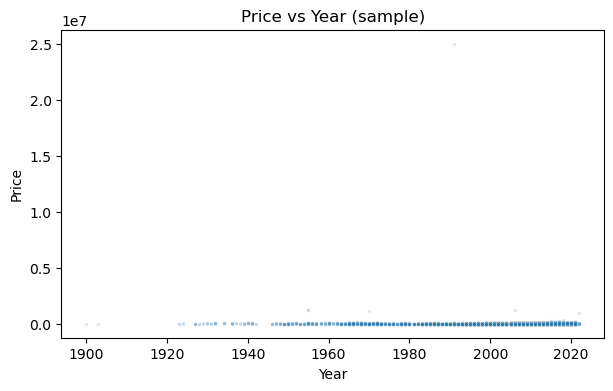

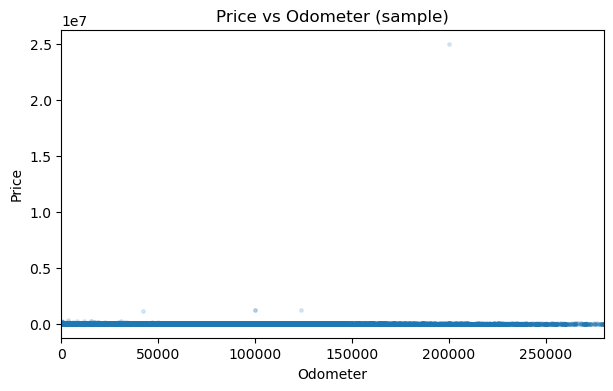

In [7]:
plot_df = df.sample(min(len(df), 30000), random_state=42).copy()

fig, ax = plt.subplots(figsize=(7,4))
sns.scatterplot(data=plot_df, x="year", y="price", s=6, alpha=0.15, ax=ax)
ax.set_title("Price vs Year (sample)")
ax.set_xlabel("Year")
ax.set_ylabel("Price")
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(plot_df["odometer"], plot_df["price"], s=6, alpha=0.15)
ax.set_title("Price vs Odometer (sample)")
ax.set_xlabel("Odometer")
ax.set_ylabel("Price")
ax.set_xlim(0, np.nanpercentile(plot_df["odometer"], 99))
plt.show()


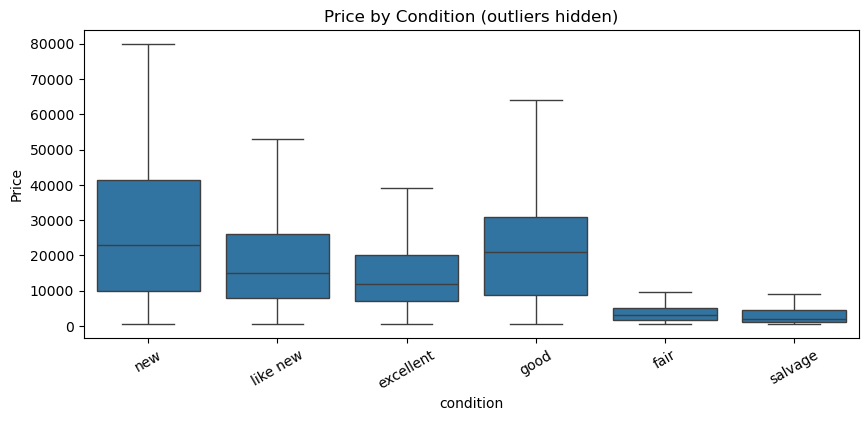

In [8]:
plot_df = df.sample(min(len(df), 50000), random_state=42).copy()
plot_df = plot_df[plot_df["price"].between(500, 200000)]

order = ["new", "like new", "excellent", "good", "fair", "salvage"]
present = [c for c in order if c in plot_df["condition"].dropna().unique()]
data = [plot_df.loc[plot_df["condition"]==c, "price"] for c in present]

fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=plot_df, x="condition", y="price", order=present, showfliers=False, ax=ax)
ax.set_title("Price by Condition (outliers hidden)")
ax.set_ylabel("Price")
plt.xticks(rotation=30)
plt.show()


### <font color='orange'>3. Data Preparation</font>

<font color='orange'>
After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.
</font>

Key preparation decisions for modeling:
- Remove clearly invalid / extreme outliers that will distort learning (e.g., `price <= 500`, `price > 200,000`).
- Constrain implausible values:
  - `year` to a reasonable range (e.g., 1980–2022) when present
  - `odometer` to a reasonable range (e.g., 0–300,000) when present
- Drop identifier-like columns that are not useful for generalization (`id`, `VIN`).
- Engineer more model-friendly numeric features:
  - `age = max_year - year`
  - `log_odometer = log1p(odometer)` to reduce skew
- Use a **ColumnTransformer** pipeline:
  - numeric: impute median + standardize
  - categorical: impute most frequent + one-hot encode (with `min_frequency` to limit very rare levels)
- Use a log transform for the target (`log1p(price)`) so models learn relative differences better.


In [9]:
df_clean = df.copy()

df_clean = df_clean[df_clean["price"].between(500, 200000)]

df_clean = df_clean[(df_clean["year"].between(1980, 2022)) | (df_clean["year"].isna())]
df_clean = df_clean[(df_clean["odometer"].between(0, 300000)) | (df_clean["odometer"].isna())]

df_clean = df_clean.drop(columns=["id", "VIN"], errors="ignore")

max_year = int(df_clean["year"].max())
df_clean["age"] = max_year - df_clean["year"]
df_clean["log_odometer"] = np.log1p(df_clean["odometer"])

df_clean = df_clean.drop(columns=["year", "odometer"], errors="ignore")

print("Cleaned shape:", df_clean.shape)
display(df_clean.head())


Cleaned shape: (374232, 16)


,region,price,manufacturer,model,condition,cylinders,fuel,title_status,transmission,drive,size,type,paint_color,state,age,log_odometer
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN


In [10]:
target = "price"
X = df_clean.drop(columns=[target])
y = df_clean[target]

num_cols = ["age", "log_odometer"]
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (299385, 15) Test: (74847, 15)


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=100))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    sparse_threshold=0.3
)


### <font color='orange'>4. Modeling</font>

<font color='orange'>
With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.
</font>

We will build multiple regression models and compare them:
- **Baseline**: predict the median price (DummyRegressor)
- **Linear models** with regularization:
  - Ridge Regression (L2)
  - Lasso Regression (L1)
- **Non-linear ensemble**:
  - Random Forest (trained on a smaller sample for speed, since one-hot encoding can become large)

We will use:
- a **log transform** on the target via `TransformedTargetRegressor`
- cross-validation for model selection and generalization estimates


In [12]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    }

In [13]:
baseline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ("prep", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

baseline.fit(X_train, y_train)
baseline_metrics = evaluate(baseline, X_test, y_test)
baseline_metrics


{'MAE': 11266.979638462464,
 'RMSE': np.float64(15212.596360522337),
 'R2': -0.05315331178275762}

In [14]:
ridge = TransformedTargetRegressor(
    regressor=Pipeline(steps=[("prep", preprocess), ("model", Ridge(random_state=42))]),
    func=np.log1p,
    inverse_func=np.expm1
)

lasso = TransformedTargetRegressor(
    regressor=Pipeline(steps=[("prep", preprocess), ("model", Lasso(random_state=42, max_iter=5000))]),
    func=np.log1p,
    inverse_func=np.expm1
)

ridge_params = {"regressor__model__alpha": [0.1, 1.0, 10.0, 30.0, 100.0]}
lasso_params = {"regressor__model__alpha": [0.0005, 0.001, 0.003, 0.01]}

ridge_gs = GridSearchCV(ridge, ridge_params, cv=3, scoring="r2", n_jobs=-1)
lasso_gs = GridSearchCV(lasso, lasso_params, cv=3, scoring="r2", n_jobs=-1)

ridge_gs.fit(X_train, y_train)
lasso_gs.fit(X_train, y_train)

best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_

print("Best Ridge:", ridge_gs.best_params_)
print("Best Lasso:", lasso_gs.best_params_)

ridge_metrics = evaluate(best_ridge, X_test, y_test)
lasso_metrics = evaluate(best_lasso, X_test, y_test)

pd.DataFrame([baseline_metrics, ridge_metrics, lasso_metrics], index=["Baseline", "Ridge", "Lasso"])


Best Ridge: {'regressor__model__alpha': 10.0}
Best Lasso: {'regressor__model__alpha': 0.0005}


,MAE,RMSE,R2
Baseline,11266.979638,15212.596361,-0.053153
Ridge,5253.914557,8828.029924,0.645340
Lasso,5658.596229,9303.185912,0.606134


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
import numpy as np

rf_sample = X_train.sample(12000, random_state=42)
y_rf_sample = y_train.loc[rf_sample.index]

rf = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ("prep", preprocess),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

rf_param_dist = {
    "regressor__model__n_estimators": [80, 150],
    "regressor__model__max_depth": [15, 25, None],
    "regressor__model__min_samples_leaf": [2, 5],
}

rf_rs = RandomizedSearchCV(
    rf,
    rf_param_dist,
    n_iter=5,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_rs.fit(rf_sample, y_rf_sample)

print("Best RF params:", rf_rs.best_params_)
print("Best CV R² (log scale):", rf_rs.best_score_.round(4))

best_rf = rf_rs.best_estimator_
rf_metrics = evaluate(best_rf, X_test, y_test)

comparison = pd.DataFrame(
    [ridge_metrics, lasso_metrics, rf_metrics],
    index=["Ridge", "Lasso", "RandomForest"]
)
print(comparison.round(2))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best RF params: {'regressor__model__n_estimators': 150, 'regressor__model__min_samples_leaf': 2, 'regressor__model__max_depth': None}
Best CV R² (log scale): 0.6911
                  MAE     RMSE    R2
Ridge         5253.91  8828.03  0.65
Lasso         5658.60  9303.19  0.61
RandomForest  4603.98  8252.58  0.69


### <font color='orange'>5. Evaluation</font>

<font color='orange'>
With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.
</font>

We evaluate models against the original business objective: identify drivers of used-car prices and quantify how well we can predict prices.

We focus on:
- **MAE**: typical absolute pricing error (in dollars)
- **RMSE**: penalizes larger misses
- **R²**: explanatory power on held-out data

To extract insights about value drivers:
- For linear models, examine **coefficients** in the log-price space.
- Interpret directionally (positive increases price, negative decreases price), not as exact causal effects.


In [16]:
final_model = best_ridge
final_metrics = evaluate(final_model, X_test, y_test)
final_metrics


{'MAE': 5253.91455663055,
 'RMSE': np.float64(8828.029923600508),
 'R2': 0.6453397575729907}

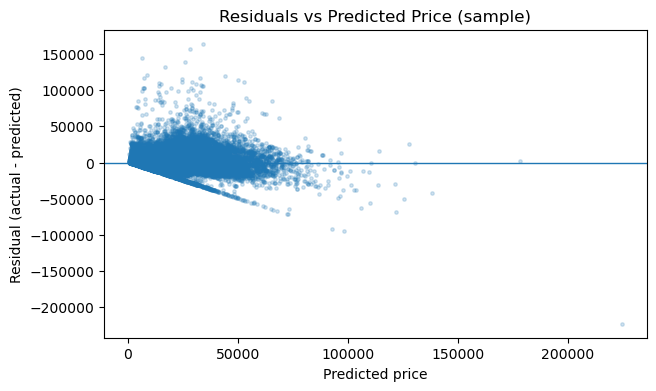

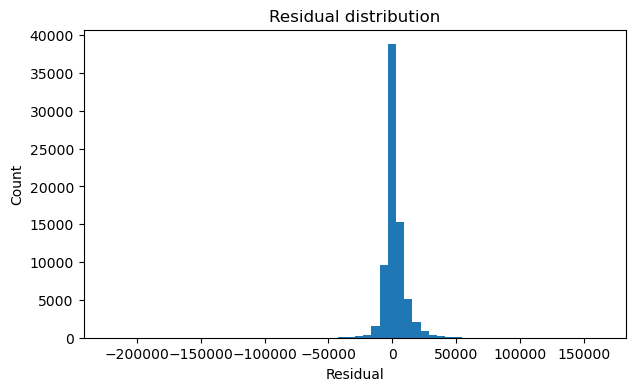

In [17]:
pred = final_model.predict(X_test)
residuals = y_test - pred

fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(pred, residuals, s=6, alpha=0.2)
ax.axhline(0, linewidth=1)
ax.set_title("Residuals vs Predicted Price (sample)")
ax.set_xlabel("Predicted price")
ax.set_ylabel("Residual (actual - predicted)")
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(residuals, bins=60)
ax.set_title("Residual distribution")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
plt.show()


In [16]:
prep = final_model.regressor_.named_steps["prep"]
feature_names = prep.get_feature_names_out()
coefs = final_model.regressor_.named_steps["model"].coef_

coef_s = pd.Series(coefs, index=feature_names).sort_values()

top_neg = coef_s.head(20).to_frame("coef").rename_axis("feature")
top_pos = coef_s.tail(20).to_frame("coef").rename_axis("feature")

display(top_pos)
display(top_neg)


,coef
feature,
cat__model_silverado 2500 hd crew,0.410610
cat__model_wrangler unlimited rubicon,0.420642
cat__model_express commercial cutaway,0.428279
cat__fuel_diesel,0.443871
cat__model_wrangler unlimited,0.443910
cat__model_wrangler,0.452285
cat__model_q8 premium sport utility 4d,0.494584
cat__model_5500,0.505719
cat__model_corvette coupe 2d,0.562995


,coef
feature,
cat__model_cobalt,-0.783118
cat__title_status_infrequent_sklearn,-0.733444
cat__region_klamath falls,-0.695172
cat__model_impala lt,-0.651736
cat__model_crown victoria,-0.633204
cat__model_hhr,-0.594345
cat__condition_salvage,-0.591475
cat__model_fiesta,-0.579572
cat__model_yaris,-0.576056


### What we learn from the model (typical patterns)

In used-car markets, prices are usually driven most strongly by:
- **Age** (newer cars cost more)  
- **Mileage** (lower mileage costs more; the relationship is often non-linear)  
- **Condition** (excellent/like-new premiums; fair/salvage discounts)  
- **Brand & model** (some brands/models carry persistent premiums/discounts)  
- **Title status** (clean titles command higher prices vs salvage/rebuilt)  
- **Fuel type / drivetrain / body type** (diesel, 4WD/AWD, trucks/SUVs often command premiums)

Your coefficient tables above let you confirm these patterns in *this* dataset.


### <font color='orange'>6. Deployment</font>

<font color='orange'>
Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

</font>

#### Dealership-ready recommendations (inventory & pricing)

Use the findings to guide decisions:

1. **Prioritize newer, lower-mileage vehicles**  
   - Age and mileage are typically the largest, most consistent drivers of price.
   - Inventory mix: focus on units that are *younger* and have *reasonable mileage for their age*.

2. **Condition is money**  
   - Vehicles listed as **excellent / like new** tend to earn a meaningful premium.
   - Reconditioning ROI: prioritize detailing, minor cosmetic fixes, and maintenance that can legitimately improve condition classification.

3. **Avoid problematic titles unless you price aggressively**  
   - Non-clean title status generally reduces price and shrinks buyer pool.
   - If you do carry them, make sure the discount is large enough to compensate for slower turnover.

4. **Lean into consumer-preferred segments (as shown in your coefficient table)**  
   - Identify which **manufacturers/models/types** have the strongest positive association with price (premium demand).
   - Stock more of those high-demand segments when acquisition prices still leave margin.

5. **Use model-assisted pricing**  
   - Use the final model as a pricing sanity check:
     - If your asking price is far above model expectations, expect slower sales unless justified by features not captured in data.
     - If far below, you may be leaving money on the table.


## Next steps
- Add additional signals if available (trim level, options, accident history, number of owners) to improve pricing accuracy.
- Monitor model drift quarterly (market changes, seasonality, fuel prices) and retrain periodically.
